Lex Albrandt  
CS445  
Final Exam  
 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression, LogisticRegression

## Question 1  
  
1a)   
A good continuous variable would be a driver's average star rating over a number  
of rides  
  
1b)   
For this linear regression model the numeric score would be a feature as well as all  
of the frequency words, which would be tokenized. The feature vector would then be all of  
the numeric score as well as the tokenized words. This could be represented in the following  
linear regression model form:  

$y = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n$   
  
1c) The numeric scores have different scales, so I would use feature scaling.  
This can either be a min/max scaling or standardization to ensure that all features  
are on the same scale.
  
## Question 2  
The parameter $C$ in a SVM balances violations and inverse of margin. If $C$ is large  
it forces the minimum number of violations, and has a small margin. This means it is  
highly fit to the data (overfitting), and also has low bias, but high variance.  If $C$  
is small, it enables more violations, but has a large margin. This means the bias is higher  
and the variance is lower. An ML engineer can find the optimal $C$ value by using cross-validation.  
  
## Question 3  
We are given that there are 5 vectors, where each eigenvalue is equal to 2. To find the total  
variance we use:  
$\sum_{j=1}^{p}=\lambda_j = 2 + 2 + 2 + 2 + 2 = 10$  
Then find the PVE for each eigenvalue:  
$PVE_k = \frac{2}{10} = 0.2$

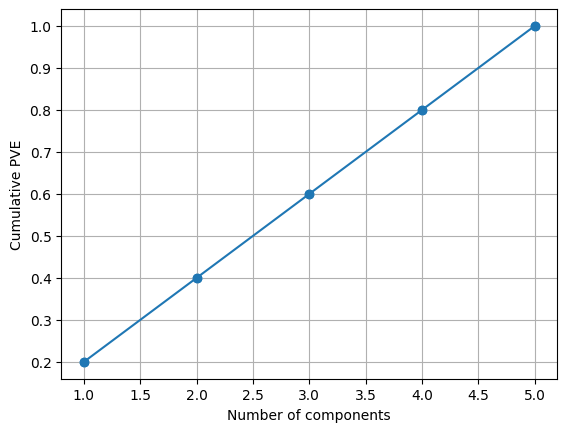

In [2]:
x = [1, 2, 3, 4, 5]
y = [0.2, 0.4, 0.6, 0.8, 1.0]

plt.scatter(x, y)
plt.plot(x, y, marker = 'o')
plt.xlabel('Number of components')
plt.ylabel('Cumulative PVE')
plt.grid(True)
plt.show()

Because each eigenvalue makes up $20%$ of the total variance, no component is more important  
than another, so dimensionality reduction would not be a good tool in this instance. This is  
because removing a single component would result in siginificant information loss.  
  
## Question 4  
  

In [3]:
rows = 10
cols = 5

# Create random matrices for feature and target
X = np.random.rand(rows, cols)
y = np.random.rand(rows)

# Split 70/30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3)

# Create scaler object
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Question 5  
  
5a)  

In [4]:
# Using X_train/test and y_train/test from previous question

# get number of features
n_features = X_train.shape[1]

# Best model using 1 feature
best_mse_1 = float('inf')
best_feature_1 = None

for i in range(n_features):
    model = LinearRegression()
    model.fit(X_train[:, [i]], y_train)
    yhat = model.predict(X_test[:, [i]])
    mse = mean_squared_error(y_test, yhat)
    if mse < best_mse_1:
        best_mse_1 = mse
        best_feature_1 = i

5b)  

In [5]:
best_mse_2 = float('inf')
best_features_2 = None

for i in range(n_features):
    for j in range(i + 1, n_features):
        model = LinearRegression()
        model.fit(X_train[:, [i, j]], y_train)
        yhat = model.predict(X_test[:, [i, j]])
        mse = mean_squared_error(y_test, yhat)
        if mse < best_mse_2:
            best_mse_2 = mse
            best_features_2 = (i, j)

## Question 6
$\frac{\partial f}{\partial x_1} = 1 + 0 = 1$  
$\frac{\partial f}{\partial x_2} = 0 + 1 \cdot x_3 = x_3$  
$\frac{\partial f}{\partial x_3} = 0 + x_2 \cdot 1 = x_2$  
  
so the final gradient is:  
$\nabla f(x) =
\begin{bmatrix}
\frac{\partial f}{\partial x_1} \\
\frac{\partial f}{\partial x_2} \\
\frac{\partial f}{\partial x_3} 
\end{bmatrix} = 
\begin{bmatrix}
1 \\
x_3 \\
x_2
\end{bmatrix}$

## Question 7  
 
7a)   

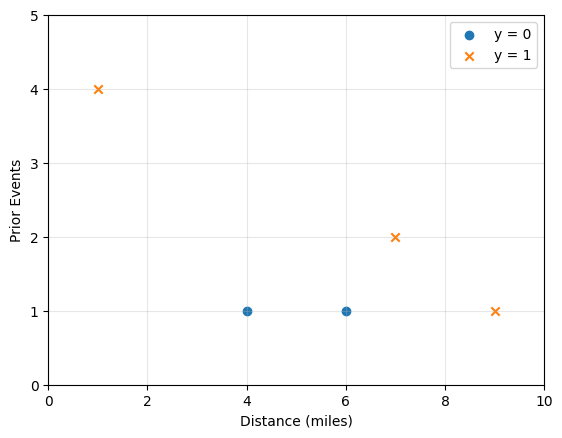

In [6]:
x1 = np.array([1, 4, 6, 7, 9])
x2 = np.array([4, 1, 1, 2, 1])
y = np.array([1, 0, 0, 1, 1])

mask0 = (y == 0)
mask1 = (y == 1)

plt.figure()
plt.scatter(x1[mask0], x2[mask0], marker = 'o', label = 'y = 0')
plt.scatter(x1[mask1], x2[mask1], marker = 'x', label = 'y = 1')

plt.xlim(0, 10)
plt.ylim(0, 5)
plt.xlabel('Distance (miles)')
plt.ylabel('Prior Events')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

7b)  
 

[[1 4]
 [4 1]
 [6 1]
 [7 2]
 [9 1]]
Weight vector w: [0.36298381 1.00164874]
Bias b: -3.3153698635550786


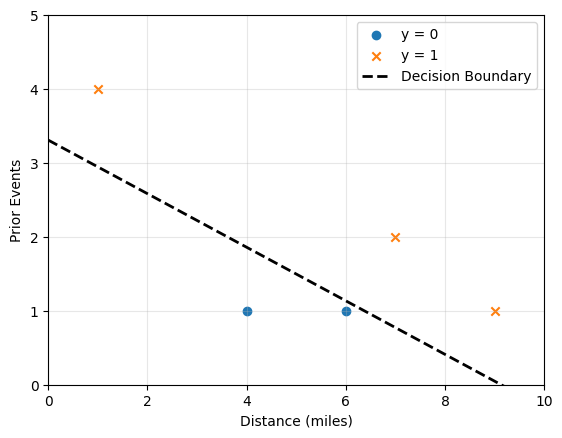

In [7]:
# Feature Matrix
X = np.column_stack((x1, x2))
print(X)

# Identify linear fit with Logistic Regression
clf = LogisticRegression()

# Decision Boundary line
# z = w1x1 + w2x2 + b
clf.fit(X, y)

# Weight and vector bias
w = clf.coef_[0]
b = clf.intercept_[0]

print(f"Weight vector w: {w}")
print(f"Bias b: {b}")

# Values for boundary line
x_vals = np.linspace(0, 10, 100)
y_vals = -(w[0] * x_vals + b) / w[1]

plt.figure()
plt.scatter(x1[mask0], x2[mask0], marker = 'o', label = 'y = 0')
plt.scatter(x1[mask1], x2[mask1], marker = 'x', label = 'y = 1')
plt.plot(x_vals, y_vals, 'k--', label = "Decision Boundary", linewidth = 2)
plt.xlim(0, 10)
plt.ylim(0, 5)
plt.xlabel('Distance (miles)')
plt.ylabel('Prior Events')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

7c)  

In [8]:
# Find z-values based on previous model
z = X @ w + b
print(f"z-values: {z}")

# convert z-values with sigmoid
p = 1 / (1 + np.exp(-z))
print(f"P(y=1)|x: {p}")
 
# find least likely sample
least_likely = np.argmin((p))
print(f"Least Likely sample: {least_likely + 1}")

z-values: [ 1.05420892 -0.86178587 -0.13581825  1.22881431  0.95313319]
P(y=1)|x: [0.74158231 0.29696636 0.46609754 0.77361098 0.72174485]
Least Likely sample: 2


The calculations above show that the sample least likely to volunteer is sample 2  
at index 1.